In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# EJERCICIO 2

PUNTO 1

In [2]:
alimentos = pd.read_csv("datasets/alimentos.csv", encoding='latin-1', delimiter=';')
pacientes = pd.read_csv("datasets/pacientes.csv", encoding='latin-1', delimiter=';')

#alimentos.info()
#alimentos.columns
#alimentos.head(15)

#pacientes.info() 
#pacientes.columns
#pacientes.head(15)

# Veo que la altura se encuentra en str, lo paso a float
pacientes['altura_m'] = pacientes['altura_m'].str.replace(',', '.')
pacientes['altura_m'] = pacientes['altura_m'].astype(float)

alimentos.info()
pacientes.info()


<class 'pandas.DataFrame'>
RangeIndex: 99 entries, 0 to 98
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   alimento              99 non-null     str  
 1   aporte_calorico_kcal  99 non-null     int64
 2   tipo_de_alimento      99 non-null     str  
 3   vitamina              99 non-null     str  
dtypes: int64(1), str(3)
memory usage: 4.9 KB
<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   codigo_paciente          50 non-null     int64  
 1   peso_inicial_kg          50 non-null     int64  
 2   peso_final_kg            50 non-null     int64  
 3   altura_m                 50 non-null     float64
 4   sexo                     50 non-null     str    
 5   tiempo_tratamiento_dias  50 non-null     int64  
dtypes: float64(1), int64(4), str(1)
memory us

PUNTO 2

In [3]:
# kcal que aportan en promedio los alimentos del dataset
alimentos['aporte_calorico_kcal'].mean()

# valor calorico que tal que el 50% de los valores del dataset son menores o igual que el (mediana)
alimentos['aporte_calorico_kcal'].median()

# valores que se presentan con mayor frecuencia
alimentos['aporte_calorico_kcal'].mode()

# variabilidad en el 50% central de los datos
riq = alimentos['aporte_calorico_kcal'].quantile(0.75) - alimentos['aporte_calorico_kcal'].quantile(0.25)
#print(riq)

PUNTO 3

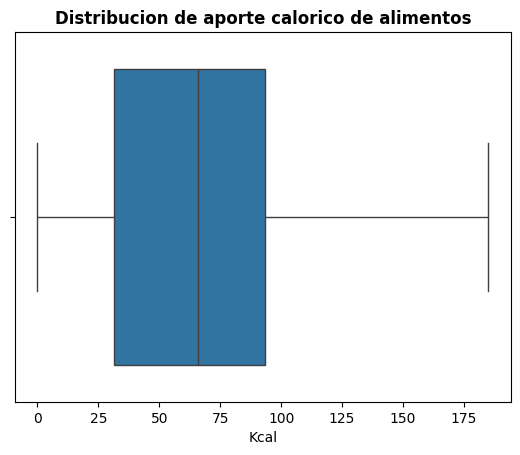

La cantidad de outliers es:  99


In [4]:
# Creo el boxplot con seaborn. Uso showfliers=False para ocultar los outliers y que asi se vea mejor el boxplot
sns.boxplot(x='aporte_calorico_kcal', data=alimentos, showfliers=False)

# Lo emprolijo con matplotlib
plt.title("Distribucion de aporte calorico de alimentos", fontweight="bold")
plt.xlabel("Kcal")
plt.show()

# Existen bastantes posiciones atipicas. Estas son las que son menores que el Q1 - (RIQ * 1.5) y mayores que el Q3 + (RIQ * 1.5)
limite_inf = alimentos['aporte_calorico_kcal'].quantile(0.75) + (riq * 1.5)
limite_sup = alimentos['aporte_calorico_kcal'].quantile(0.25) - (riq * 1.5)
outliers = alimentos[(alimentos['aporte_calorico_kcal'] < limite_inf) | (alimentos['aporte_calorico_kcal'] > limite_sup)]
cant_outliers = len(outliers)
print("La cantidad de outliers es: ", cant_outliers)

# Se nota una clara asimetria hacia la derecha de de la distribucion
# Para describir este conjunto de datos las medidas mas adecuadas me parecen: la mediana y el RIQ, ya que estas no se ven 
# tan afectadas por los outliers

PUNTO 4

In [5]:
# Agrupo por alimentos y trabajo con la columna de aporte calorico, y de ahi saco la media de cada grupo y el maximo id
alimento_mayor_media = alimentos.groupby('alimento')['aporte_calorico_kcal'].median().idxmax()

print("El alimento con mayor media es: ", alimento_mayor_media)
alimentos.head(15)

El alimento con mayor media es:   hamburguesa


,alimento,aporte_calorico_kcal,tipo_de_alimento,vitamina
0,banana,81,fruta,A
1,kiwi,36,fruta,B
2,higo,62,fruta,B
3,repollo,22,verdura,A
4,col,12,verdura,A
5,guisantes,17,verdura,C
6,hamburguesa,954,elaborada,A
7,kaki,63,fruta,A
8,pasas,0,fruto seco,B
9,pan de ajo,73,elaborada,A


PUNTO 5

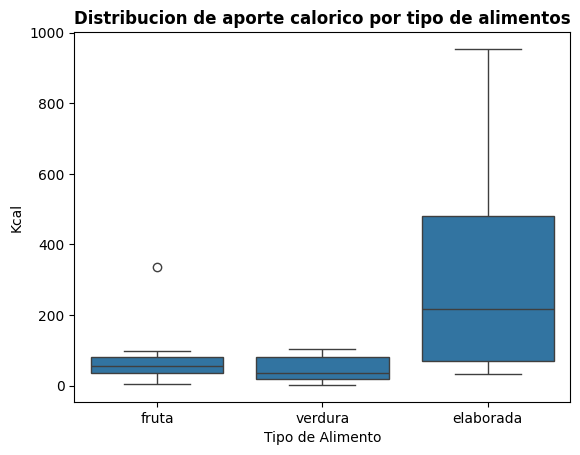

In [6]:
# Hago el grafico con seaborn y filtro los alimentos pedidos directamente en la parte de data 
sns.boxplot(x='tipo_de_alimento', y='aporte_calorico_kcal', data=alimentos[alimentos['tipo_de_alimento'].str.contains('fruta|verdura|elaborada')])

plt.title("Distribucion de aporte calorico por tipo de alimentos", fontweight="bold")
plt.xlabel("Tipo de Alimento")
plt.ylabel("Kcal")
plt.show()

Los alimentos del tipo elaborado presentan un rango variable mayor que los demas. Para denotar esto utilizamos el RIQ. Taambien lo podemos notar con el coeficiente de variacion

PUNTO 6

In [7]:
# Creo una nueva columna para guardar estos datos en el mismo df
pacientes['variacion_peso_kg'] = pacientes['peso_inicial_kg'] - pacientes['peso_final_kg']

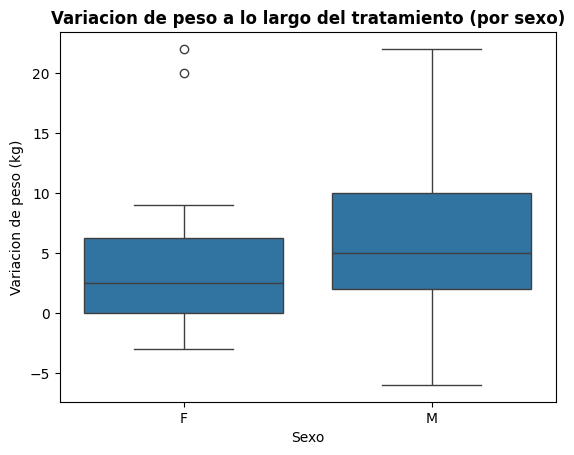

In [8]:
# Creamos el boxplot
sns.boxplot(x='sexo', y='variacion_peso_kg', data=pacientes)

# Mejoras con matplotlib
plt.title("Variacion de peso a lo largo del tratamiento (por sexo)", fontweight="bold")
plt.xlabel("Sexo")
plt.ylabel("Variacion de peso (kg)")
plt.show()

Para describir este tratamiento de la manera mas acertada, utilizaria la mediana comparar el resultado tipico, 
y el RIQ para notar la variabilidad; dada la presencia de valores atipicos.

Las personas de sexo masculino (M) fueron las que mejores resultados obtuvieron, ya que el RIQ comienza (Q1) en aproximadamente 2.5kg, a diferencia del sexo femenino que el Q1 comienza en 0kg.

# EJERCICIO 3

In [9]:
tripulantes = pd.read_csv("datasets/titanic.csv")

# Informacion general sobre el dataset y sus columnas
tripulantes.info()

<class 'pandas.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 21 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1309 non-null   int64  
 1   Survived     891 non-null    float64
 2   Pclass       1309 non-null   int64  
 3   Name         1309 non-null   str    
 4   Sex          1309 non-null   str    
 5   Age          1046 non-null   float64
 6   SibSp        1309 non-null   int64  
 7   Parch        1309 non-null   int64  
 8   Ticket       1309 non-null   str    
 9   Fare         1308 non-null   float64
 10  Cabin        295 non-null    str    
 11  Embarked     1307 non-null   str    
 12  WikiId       1304 non-null   float64
 13  Name_wiki    1304 non-null   str    
 14  Age_wiki     1302 non-null   float64
 15  Hometown     1304 non-null   str    
 16  Boarded      1304 non-null   str    
 17  Destination  1304 non-null   str    
 18  Lifeboat     502 non-null    str    
 19  Body         130 

notamos datos faltantes en: survived, age, cabin, lifeboat, body

In [10]:
tripulantes.head(15)

# Para ver la cantidad de nulos por columnas
tripulantes.isnull().sum()

PassengerId       0
Survived        418
Pclass            0
Name              0
Sex               0
Age             263
SibSp             0
Parch             0
Ticket            0
Fare              1
Cabin          1014
Embarked          2
WikiId            5
Name_wiki         5
Age_wiki          7
Hometown          5
Boarded           5
Destination       5
Lifeboat        807
Body           1179
Class             5
dtype: int64

In [11]:
# vista la cantidad de NaN de las columnas: cabin, 
# lifeboat, body. Lo mas conveniente es borrarlas ya que no 
# podemos inventar esa cantidad de datos. Eso arruinaria cualquier
# analisis estadistico o modelo predictivo que querramos hacer despues.


# EJERCICIO 4

In [12]:
# Primero fijamos los minimos y maximos de la columna altura
menor_altura = pacientes['altura_m'].min()
mayor_altura = pacientes['altura_m'].max()

# Ahora definimos los limites con estos valores calculados usando arange de numpy
limites = np.arange(menor_altura, mayor_altura + 0.1, 0.1)

# Usamos el metodo cut de pandas para generar una nueva columna donde para cada paciente se le asigne un rango 
# adecuado segun su altura
pacientes['rango_altura'] = pd.cut(x=pacientes['altura_m'], bins=limites, right=False)

# Primero calculamos las frecuencias absolutas para cada rango de altura
frec_absolutas = pacientes['rango_altura'].value_counts()

# Luego calculamos las frecuencias relativas agregando el parametro normalize
frec_relativas = pacientes['rango_altura'].value_counts(normalize=True)
#frec_relativas = frec_absolutas / len(pacientes)

# Y acumulamos las frecuencias con el metodo cumsum (cumulativ sum)
frec_relativas_acum = frec_relativas.cumsum()

# Ahora armamos la tabla de frecuencias
tabla_frecuencias = pd.DataFrame({
    'Frecuencia Absoluta': frec_absolutas,
    'Frecuencia Relativa': frec_relativas,
    'Frecuencia relativa acumulada': frec_relativas_acum
})

tabla_frecuencias

,Frecuencia Absoluta,Frecuencia Relativa,Frecuencia relativa acumulada
rango_altura,,,
"[1.6, 1.7)",20,0.40,0.40
"[1.5, 1.6)",12,0.24,0.64
"[1.7, 1.8)",11,0.22,0.86
"[1.8, 1.9)",7,0.14,1.00


# EJERCICIO 5

PUNTO 1

In [13]:
quality = pd.read_excel("datasets/wine_quality.xlsx", header=2)
aging = pd.read_csv("datasets/wine_aging.csv", sep=';')

#quality.info()
#aging.info()

# Limpieza y adecuacion
aging['aging'] = aging['aging'].str.replace({'Reserva' : 'reserva', 'granreserva' : 'gran reserva'})
aging.rename(columns= {'WINE_id':'id'}, inplace=True)
#aging['aging'].unique()

quality['quality'] = quality['quality'].str.replace({';' : '.'})
quality['quality'] = quality['quality'].astype(float)
#quality.head(15)



In [14]:
# Fusionamos datasets para mayor comodidad
vinos = pd.merge(aging, quality, on='id')

PUNTO 2

In [15]:
# Tipo de vino que presenta la mayor mediana para el sabor
vinos.groupby('aging')['flavor'].median().idxmax()

'gran reserva'

PUNTO 3

In [16]:
# Esta matriz de covarianza nos dice como varia una variable con respecto a la otra.
vinos[['clarity', 'aroma', 'body', 'flavor', 'quality']].cov()

,clarity,aroma,body,flavor,quality
clarity,0.016141,0.007601,-0.019752,0.023288,0.016183
aroma,0.007601,1.352673,0.251468,0.493862,0.994257
body,-0.019752,0.251468,0.740010,0.191799,0.456799
flavor,0.023288,0.493862,0.191799,1.291384,1.253358
quality,0.016183,0.994257,0.456799,1.253358,4.520068


PUNTO 4

In [17]:
# Al igual que la de covarianza, esta matriz nos dice como varia una variable con respecto a la otra 
# pero con la diferencia de que esta posee una estandarizacion. 
vinos[['clarity', 'aroma', 'body', 'flavor', 'quality']].corr().round(2)

,clarity,aroma,body,flavor,quality
clarity,1.00,0.05,-0.18,0.16,0.06
aroma,0.05,1.00,0.25,0.37,0.40
body,-0.18,0.25,1.00,0.20,0.25
flavor,0.16,0.37,0.20,1.00,0.52
quality,0.06,0.40,0.25,0.52,1.00


PUNTO 5

<Axes: xlabel='flavor', ylabel='quality'>

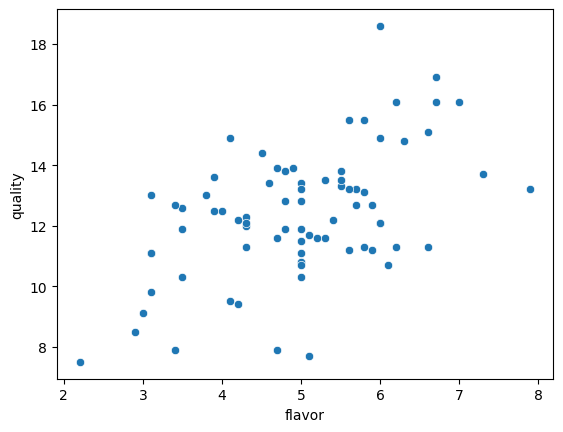

In [18]:
# Elejimos las dos variables que tienen la relacion mas fuerte (flavor, quality. Con una relacion de 0.518770)
sns.scatterplot(x='flavor', y='quality', data=vinos)

# EJERCICIO 6

In [19]:
calidad_prod = pd.read_csv("datasets/calidad_producto.csv", sep=';')
calidad_prod.info()
calidad_prod.describe()
calidad_prod.head(15)

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   desviacion_largo         200 non-null    float64
 1   indice_calidad_producto  200 non-null    float64
dtypes: float64(2)
memory usage: 3.3 KB


,desviacion_largo,indice_calidad_producto
0,-1.09000,-0.744
1,0.99700,0.720
2,-0.57900,-0.548
3,1.27000,0.935
4,1.49000,0.942
5,2.21000,0.984
6,0.73700,0.421
7,-1.25000,-0.759
8,-0.14000,-0.387
9,-1.77000,-1.030


PUNTO 1

In [20]:
calidad_prod.corr()

,desviacion_largo,indice_calidad_producto
desviacion_largo,1.000000,0.561225
indice_calidad_producto,0.561225,1.000000


In [21]:
calidad_prod.corr(method="spearman")

,desviacion_largo,indice_calidad_producto
desviacion_largo,1.000000,0.940055
indice_calidad_producto,0.940055,1.000000


### En conclusion:
El metodo de Pearson tiene un valor  de 0.57, lo que nos quiere decir que la relacion LINEAL entre las variables es baja, a comparacion de la correlacion de Spearman, que evalua relaciones monotonicas, nos dio un valor de 0.940055, indica que hay una relacion fuerte entre estar variables.

PUNTO 2

<Axes: xlabel='desviacion_largo', ylabel='indice_calidad_producto'>

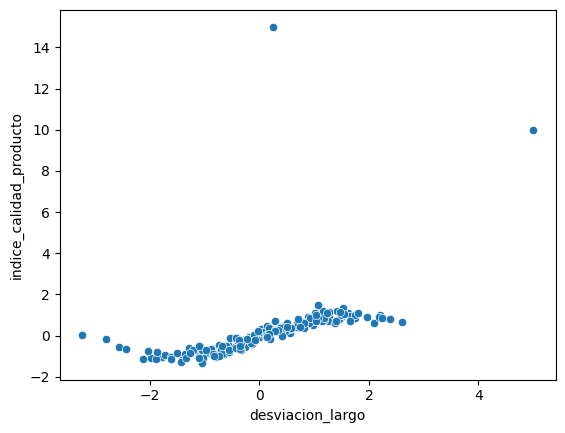

In [22]:
sns.scatterplot(x='desviacion_largo', y='indice_calidad_producto', data=calidad_prod)

PUNTO 3

In [23]:
# 1. Límites para la primera variable (Eje X)
Q1_x = calidad_prod['desviacion_largo'].quantile(0.25)
Q3_x = calidad_prod['desviacion_largo'].quantile(0.75)
RIC_x = Q3_x - Q1_x
lim_inf_x = Q1_x - 1.5 * RIC_x
lim_sup_x = Q3_x + 1.5 * RIC_x

# 2. Límites para la segunda variable (Eje Y)
Q1_y = calidad_prod['indice_calidad_producto'].quantile(0.25)
Q3_y = calidad_prod['indice_calidad_producto'].quantile(0.75)
RIC_y = Q3_y - Q1_y
lim_inf_y = Q1_y - 1.5 * RIC_y
lim_sup_y = Q3_y + 1.5 * RIC_y

calidad_prod_filtrado = calidad_prod[(calidad_prod['desviacion_largo'] <= lim_sup_x) & (calidad_prod['desviacion_largo'] >= lim_inf_x) 
                                    & (calidad_prod['indice_calidad_producto'] <= lim_sup_y) & (calidad_prod['indice_calidad_producto'] >= lim_inf_y)]

In [24]:
calidad_prod_filtrado.corr(method='pearson')

,desviacion_largo,indice_calidad_producto
desviacion_largo,1.000000,0.901743
indice_calidad_producto,0.901743,1.000000


In [25]:
calidad_prod_filtrado.corr(method='spearman')

,desviacion_largo,indice_calidad_producto
desviacion_largo,1.000000,0.950463
indice_calidad_producto,0.950463,1.000000


<Axes: xlabel='desviacion_largo', ylabel='indice_calidad_producto'>

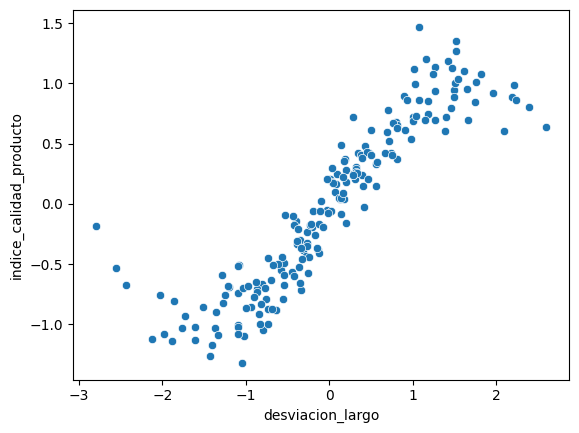

In [26]:
sns.scatterplot(x='desviacion_largo', y='indice_calidad_producto', data=calidad_prod_filtrado)

Notamos ahora, sin valores outliers, como cambia la cosa y se ve una clara relacion lineal fuerte entre las variables. Nos lo confirman el valor de la correlacion de Pearson (0.901743, antes era: 0.561225), donde evidentemente antes sufria mucho los valores ouliers, y el grafico post limpieza.

PUNTO 4

Luego de haber realizado estos pasos, concluimos que la correlacion de Pearson es la mejor para describir a estas dos variables (luego de limpiar ourliers), ya que se ve claramente que tienen una relacion lineal fuerte. Pero en un primer lugar, donde no hicimos una limpieza, lo mejor seria usar Spearman

# EJERCICIO 7

In [42]:
meteorologia = pd.read_csv("datasets/estacion_meteorologica.csv", sep=';', decimal=',')
meteorologia.info()

<class 'pandas.DataFrame'>
RangeIndex: 4464 entries, 0 to 4463
Data columns (total 19 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   No          4464 non-null   int64  
 1   Date        4464 non-null   str    
 2   Time        4464 non-null   str    
 3   ColdJunc0   4464 non-null   float64
 4   PowerVolt   4464 non-null   float64
 5   PowerKind   4464 non-null   int64  
 6   WS(ave)     4464 non-null   float64
 7   WD(ave)     4464 non-null   int64  
 8   WS(max)     4464 non-null   float64
 9   WD(most)    4464 non-null   str    
 10  WS(inst_m)  4464 non-null   float64
 11  WD(inst_m)  4464 non-null   int64  
 12  Max_time    4464 non-null   str    
 13  Solar_rad   4464 non-null   float64
 14  TEMP        4464 non-null   float64
 15  Humidity    4464 non-null   float64
 16  Rainfall    4464 non-null   float64
 17  Bar_press.  4464 non-null   float64
 18  Soil_temp   4464 non-null   float64
dtypes: float64(11), int64(4), str(4)
memor

In [43]:
meteorologia.head(15)

,No,Date,Time,ColdJunc0,PowerVolt,PowerKind,WS(ave),WD(ave),WS(max),WD(most),WS(inst_m),WD(inst_m),Max_time,Solar_rad,TEMP,Humidity,Rainfall,Bar_press.,Soil_temp
0,92793,1/10/2021,0:00:00,22.6,13.0,2,0.4,19,0.9,NE,1.9,43,23:50:41,0.0,22.5,82.39,0.0,1000.0,0.0
1,92794,1/10/2021,0:10:00,22.5,13.0,2,1.0,131,1.0,ESE,4.3,161,0:04:57,0.0,22.3,84.09,0.0,1000.0,0.0
2,92795,1/10/2021,0:20:00,22.5,13.0,2,0.8,166,1.0,ESE,3.7,145,0:13:00,0.0,22.7,81.99,0.0,1000.0,0.0
3,92796,1/10/2021,0:30:00,22.5,13.0,2,0.7,205,0.8,WSW,3.1,160,0:25:55,0.0,22.2,84.29,0.0,1000.0,0.0
4,92797,1/10/2021,0:40:00,22.5,12.9,2,0.6,134,0.7,E,4.3,121,0:35:35,0.0,21.8,87.90,0.0,999.7,0.0
5,92798,1/10/2021,0:50:00,22.4,13.0,2,0.2,124,0.6,SSE,1.9,51,0:47:12,0.0,21.6,89.40,0.0,999.6,0.0
6,92799,1/10/2021,1:00:00,22.2,13.0,2,0.8,7,0.8,NNE,2.5,54,0:51:29,0.0,21.5,90.20,0.0,999.2,0.0
7,92800,1/10/2021,1:10:00,22.1,12.9,2,0.9,52,0.9,NE,5.5,291,1:09:59,0.0,21.4,91.10,0.0,999.1,0.0
8,92801,1/10/2021,1:20:00,22.0,12.9,2,0.9,206,1.1,SSW,5.5,215,1:11:09,0.0,21.2,92.60,0.0,999.1,0.0
9,92802,1/10/2021,1:30:00,21.9,13.0,2,0.6,152,0.9,SE,3.7,145,1:20:30,0.0,21.2,93.60,0.0,999.1,0.0


In [48]:
meteorologia_cuantitativos = meteorologia[['No', 'ColdJunc0', 'PowerVolt', 'WS(ave)',
       'WD(ave)', 'WS(max)', 'WS(inst_m)', 'WD(inst_m)', 'Solar_rad', 'TEMP', 'Humidity', 'Rainfall', 'Bar_press.',
       'Soil_temp']]

In [50]:
meteorologia_cuantitativos.corr().round(2)

,No,ColdJunc0,PowerVolt,WS(ave),WD(ave),WS(max),WS(inst_m),WD(inst_m),Solar_rad,TEMP,Humidity,Rainfall,Bar_press.,Soil_temp
No,1.00,0.04,0.01,0.10,0.10,0.09,0.09,0.10,-0.07,0.10,0.05,0.01,0.44,-0.05
ColdJunc0,0.04,1.00,0.49,0.20,-0.37,0.21,0.07,-0.36,0.80,0.98,-0.96,-0.01,-0.37,0.71
PowerVolt,0.01,0.49,1.00,-0.13,-0.13,-0.14,-0.21,-0.13,0.48,0.46,-0.44,-0.01,0.04,0.20
WS(ave),0.10,0.20,-0.13,1.00,0.02,0.96,0.91,-0.02,0.05,0.22,-0.22,-0.01,-0.25,0.14
WD(ave),0.10,-0.37,-0.13,0.02,1.00,0.01,0.09,0.64,-0.28,-0.37,0.37,-0.04,0.24,-0.31
WS(max),0.09,0.21,-0.14,0.96,0.01,1.00,0.90,-0.02,0.06,0.23,-0.23,-0.02,-0.25,0.15
WS(inst_m),0.09,0.07,-0.21,0.91,0.09,0.90,1.00,0.06,-0.07,0.09,-0.10,-0.02,-0.21,0.05
WD(inst_m),0.10,-0.36,-0.13,-0.02,0.64,-0.02,0.06,1.00,-0.27,-0.37,0.37,-0.04,0.25,-0.29
Solar_rad,-0.07,0.80,0.48,0.05,-0.28,0.06,-0.07,-0.27,1.00,0.74,-0.77,-0.01,-0.09,0.66
TEMP,0.10,0.98,0.46,0.22,-0.37,0.23,0.09,-0.37,0.74,1.00,-0.96,-0.01,-0.39,0.70
